# 05 — FastICA : identification des composantes du signal (multi-stations)

## Objectif
Décomposer les séries de température d’eau multi-stations en composantes indépendantes afin d’identifier :
- une composante saisonnière annuelle,
- une composante intra-journalière (jour/nuit),
- des composantes locales (effet station),
et relier ces composantes à des variables calendaires et/ou exogènes.

## Plan
1. Setup + chargement + split
2. Construction matrice (temps × stations) sur TRAIN
3. Standardisation (fit TRAIN) + FastICA (fit TRAIN)
4. Analyse : composantes dans le temps + poids par station + corr avec calendrier
5. Export des composantes ICA comme features

## 1. Setup + config + MLflow


In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA


PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "base1_clean.parquet"
FIG_DIR   = PROJECT_ROOT / "reports" / "figures" / "05_ica"

# Artifacts Notebook 05 
ART_05      = PROJECT_ROOT / "artifacts" / "05_ica"
ART_05_TBL  = ART_05 / "tables"
ART_05_FEAT = ART_05 / "features"
ART_05_PLT  = ART_05 / "plots"
ART_05_SUM  = ART_05 / "summary"

#  Config 
CONFIG_DIR  = PROJECT_ROOT / "configs"
CONFIG_PATH = CONFIG_DIR / "ts_config.json"

for p in [FIG_DIR, ART_05, ART_05_TBL, ART_05_FEAT, ART_05_PLT, ART_05_SUM, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [2]:
# Constantes dataset
ID_COL = "id_sonde"
TS_COL = "ts"
TARGET = "temp_water_c"
EXPECTED_FREQ = pd.Timedelta(hours=2)

# FastICA hyperparameter
ICA_N_COMPONENTS = 3
ICA_RANDOM_STATE = 42
ICA_MAX_ITER = 2000
ICA_TOL = 1e-4

In [3]:
# Charger config (split, horizons...)
assert CONFIG_PATH.exists(), f"Config introuvable: {CONFIG_PATH}"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

SEED = int(CFG["seed"])
VAL_START = pd.Timestamp(CFG["val_start"])
TEST_START = pd.Timestamp(CFG["test_start"])
HORIZONS = {k: int(v) for k, v in CFG.get("horizons_steps_2h", {}).items()}

np.random.seed(SEED)

In [4]:
# MLflow - setup robuste 

USE_MLFLOW = True

if USE_MLFLOW:
    import mlflow
    from mlflow.tracking import MlflowClient

    BASE_EXP_NAME = "river_temp_ts" 
    MLFLOW_DIR = PROJECT_ROOT / "mlflow"
    MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

    # DB metadata
    DB_PATH = (MLFLOW_DIR / "mlflow.db").resolve()

    # Artifacts 
    MLRUN_DIR = (MLFLOW_DIR / "mlrun").resolve()
    MLRUN_DIR.mkdir(parents=True, exist_ok=True)

    mlflow.set_tracking_uri(f"sqlite:///{DB_PATH.as_posix()}")
    artifact_root = MLRUN_DIR.as_uri() 

    client = MlflowClient()
    exp = client.get_experiment_by_name(BASE_EXP_NAME)

    def _new_exp_name():
        return f"{BASE_EXP_NAME}_{datetime.now():%Y%m%d_%H%M%S}"

    if exp is None:
        exp_id = client.create_experiment(BASE_EXP_NAME, artifact_location=artifact_root)
        exp = client.get_experiment(exp_id)
    else:
        bad_state = (exp.lifecycle_stage != "active")
        bad_art_root = (exp.artifact_location != artifact_root)

        if bad_state or bad_art_root:
            exp_name = _new_exp_name()
            exp_id = client.create_experiment(exp_name, artifact_location=artifact_root)
            exp = client.get_experiment(exp_id)

    mlflow.set_experiment(experiment_id=exp.experiment_id)

    print("\n[MLflow]")
    print("tracking URI  :", mlflow.get_tracking_uri())
    print("experiment    :", exp.name)
    print("experiment ID :", exp.experiment_id)
    print("lifecycle     :", exp.lifecycle_stage)
    print("artifact root :", exp.artifact_location)


[MLflow]
tracking URI  : sqlite:///C:/Users/El-fahad COMBO/Desktop/Serie_temporelle/Mlflow/mlflow.db
experiment    : river_temp_ts_20260225_191303
experiment ID : 20
lifecycle     : active
artifact root : file:///C:/Users/El-fahad%20COMBO/Desktop/Serie_temporelle/Mlflow/mlrun


## 2 — Chargement + matrice (temps × stations) + split

Objectif : construire la matrice `X_wide` où chaque colonne est une station et chaque ligne un timestamp.
On vérifie l’alignement (pas de NA) et on découpe train/val/test , en gardant en tête que le fit ICA sera fait uniquement sur TRAIN.

In [5]:
# Chargement
df = pd.read_parquet(DATA_PATH).copy()
df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")

df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)

# Pivot: temps x stations
X_wide = (df.pivot(index=TS_COL, columns=ID_COL, values=TARGET).sort_index())

print("X_wide shape (n_timestamps, n_stations):", X_wide.shape)
print("Stations (cols):", list(X_wide.columns))
print("Missing total in X_wide:", int(X_wide.isna().sum().sum()))

## Split temporelle — Fit scaler+ICA sur TRAIN seulement

X_train = X_wide.loc[X_wide.index < VAL_START].copy()
X_val   = X_wide.loc[(X_wide.index >= VAL_START) & (X_wide.index < TEST_START)].copy()
X_test  = X_wide.loc[X_wide.index >= TEST_START].copy()

print("Shapes train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("NA train / val / test:",
      int(X_train.isna().sum().sum()),
      int(X_val.isna().sum().sum()),
      int(X_test.isna().sum().sum()))

display(X_wide.head(3))
display(X_train.tail(3))

X_wide shape (n_timestamps, n_stations): (23458, 7)
Stations (cols): [817, 818, 819, 825, 827, 828, 830]
Missing total in X_wide: 0
Shapes train/val/test: (20129, 7) (2172, 7) (1157, 7)
NA train / val / test: 0 0 0


id_sonde,817,818,819,825,827,828,830
ts,,,,,,,
2013-05-29 14:00:00,12.703,13.401,13.610,9.682,11.321,11.467,11.783
2013-05-29 16:00:00,12.896,13.594,13.826,10.075,11.734,11.929,12.050
2013-05-29 18:00:00,12.968,13.906,14.042,10.614,12.243,12.098,13.401


id_sonde,817,818,819,825,827,828,830
ts,,,,,,,
2017-12-31 18:00:00,9.064,9.213,9.013,8.965,9.879,10.100,10.149
2017-12-31 20:00:00,9.015,9.188,8.988,8.990,9.756,9.977,10.075
2017-12-31 22:00:00,8.841,9.163,8.963,9.015,9.558,9.780,10.001


### Résultats — matrice (temps × stations) et découpage temporel

Nous chargeons le dataset nettoyé et construisons une matrice large `X_wide` (index = timestamps, colonnes = stations, valeur = `temp_water_c`).
Cette représentation est nécessaire pour FastICA, qui cherche des composantes indépendantes à partir des signaux multi-stations observés simultanément.

Résultats :
- `X_wide` contient 23 458 timestamps et 7 stations (`shape = (23458, 7)`).
- Aucune valeur manquante n’est présente (`Missing total = 0`), y compris après découpage train/val/test.
- Découpage temporel :
  - train : 20 129 timestamps (2013–2017)
  - val : 2 172 timestamps (2018-01 → 2018-06)
  - test : 1 157 timestamps (2018-07 → 2018-10)

Les étapes suivantes ajusteront la standardisation et FastICA uniquement sur la période train, puis transformeront val/test sans refit .

## 3 — Standardisation (fit TRAIN) + FastICA (fit TRAIN)

On standardise les 7 séries (colonnes = stations) sur la période train, puis on ajuste FastICA sur train.
Sorties :
- `S_train` : composantes indépendantes (IC) dans le temps (train).
- `A_df` : mixing matrix (poids/chargements par station pour chaque IC).

Anti-leakage : scaler + ICA sont **fit uniquement sur TRAIN** ; val/test seront transformés sans refit à la cellule suivante.

In [6]:
#1 Standardisation (fit TRAIN slmnt)
scaler = StandardScaler()
Xtr_z = scaler.fit_transform(X_train.values)

#2 FastICA (fit TRAIN slmnt)
ica = FastICA(
    n_components=ICA_N_COMPONENTS,
    random_state=ICA_RANDOM_STATE,
    whiten="unit-variance",
    max_iter=ICA_MAX_ITER,
    tol=ICA_TOL,)

S_tr = ica.fit_transform(Xtr_z)         
A = ica.mixing_                          

ic_cols = [f"IC{k+1}" for k in range(ICA_N_COMPONENTS)]
S_train = pd.DataFrame(S_tr, index=X_train.index, columns=ic_cols)
A_df = pd.DataFrame(A, index=X_train.columns, columns=ic_cols)

print("S_train shape:", S_train.shape)
print("A_df shape:", A_df.shape)
display(A_df)

# Export tables 
A_path = ART_05_TBL / "fastica_mixing_matrix.csv"
S_path = ART_05_TBL / "fastica_sources_train.csv"
A_df.to_csv(A_path)
S_train.to_csv(S_path)
print("Saved:", A_path)
print("Saved:", S_path)

S_train shape: (20129, 3)
A_df shape: (7, 3)


,IC1,IC2,IC3
id_sonde,,,
817,0.199268,0.902553,-0.376384
818,0.215856,0.911135,-0.348772
819,0.215827,0.911509,-0.347596
825,-0.097169,0.970453,-0.220810
827,0.028095,0.845461,-0.528128
828,0.059931,0.855075,-0.512365
830,0.091252,0.861053,-0.487890


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\tables\fastica_mixing_matrix.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\tables\fastica_sources_train.csv


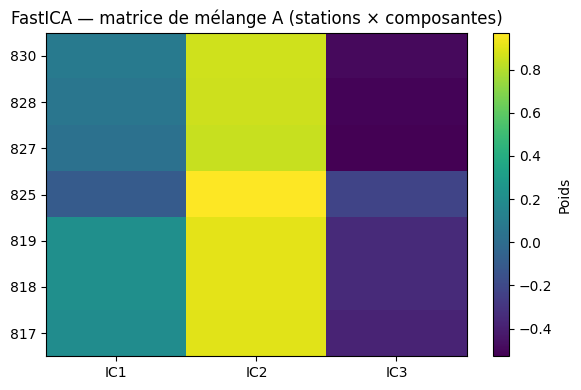

In [7]:
plt.figure(figsize=(6, 4))
plt.imshow(A_df.values, aspect="auto", origin="lower")
plt.title("FastICA — matrice de mélange A (stations × composantes)")
plt.xticks(ticks=np.arange(len(A_df.columns)), labels=A_df.columns)
plt.yticks(ticks=np.arange(len(A_df.index)), labels=A_df.index)
plt.colorbar(label="Poids")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_ica_mixing_matrix_A.png", dpi=200, bbox_inches="tight")
plt.show()

### Résultats — poids par station (`A_df`)

- La composante **IC2** présente des poids élevés et homogènes sur toutes les stations : elle correspond à une composante **globale** du signal (interprétée comme saisonnière).

- La composante **IC3** montre des différences de poids plus marquées selon les stations (notamment 827/828/830), ce qui suggère une composante plus **locale / stationnelle**.

- La composante **IC1** a des poids plus faibles et un contraste spatial plus modéré : elle semble capturer une variabilité secondaire.

## 4. Analyse visuelle des composantes


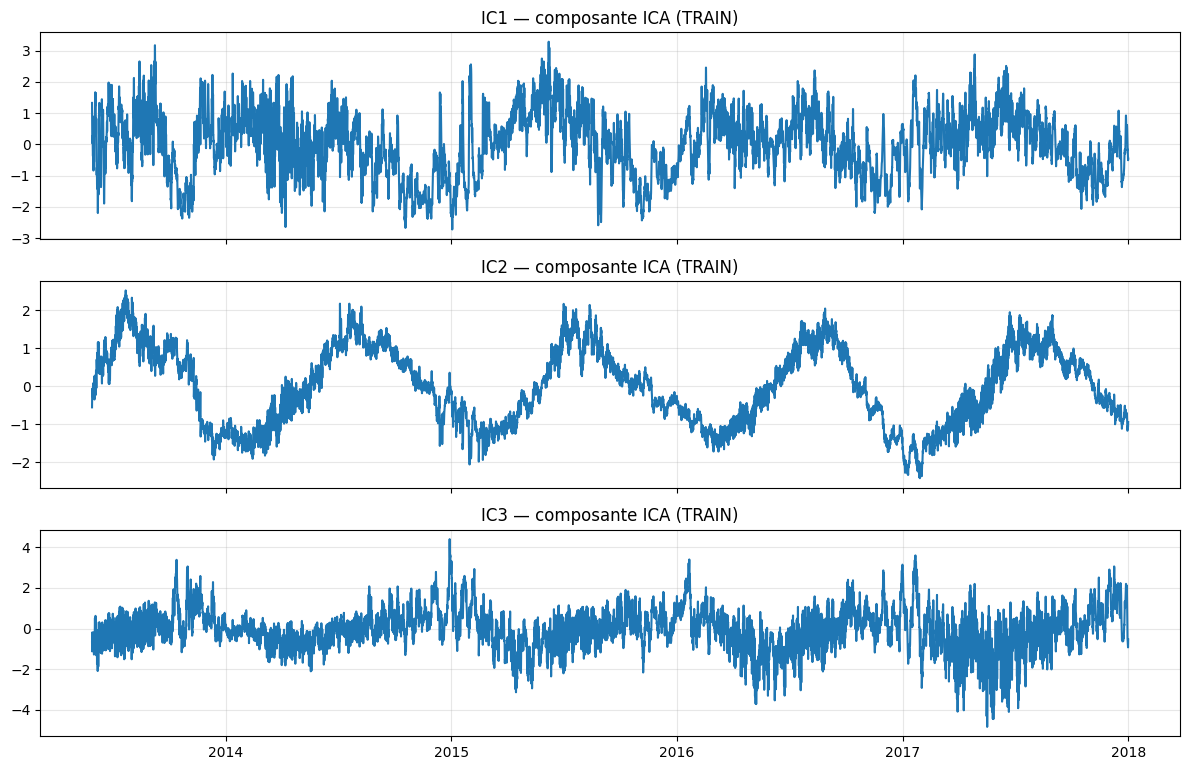

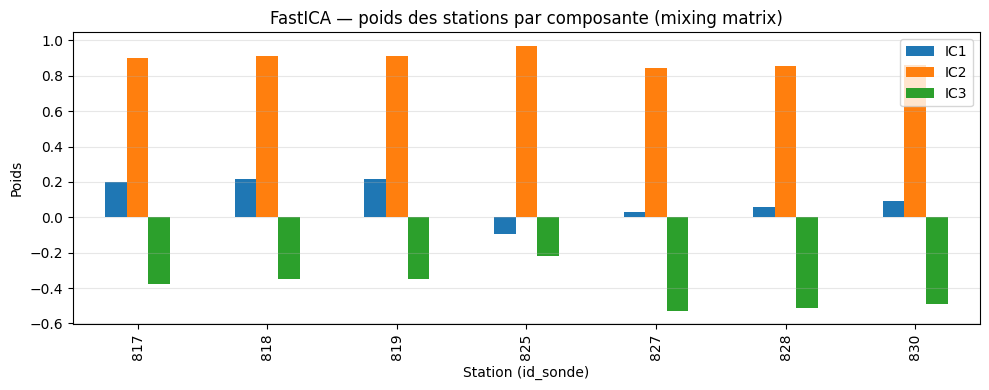

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\plots\fastica_sources_train.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\plots\fastica_mixing_matrix_bar.png


In [ ]:
# Analyse visuelle FastICA

# Plots des composantes dans le temps (TRAIN)
fig, axes = plt.subplots(ICA_N_COMPONENTS, 1, figsize=(12, 2.6 * ICA_N_COMPONENTS), sharex=True)

if ICA_N_COMPONENTS == 1:
    axes = [axes]

for i, col in enumerate(S_train.columns):
    axes[i].plot(S_train.index, S_train[col].values)
    axes[i].set_title(f"{col} — composante ICA (TRAIN)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
fig_scores_path = ART_05_PLT / "fastica_sources_train.png"
fig_scores_path2 = FIG_DIR / "fig_ica_sources_train.png"
plt.savefig(fig_scores_path, dpi=160)
plt.savefig(fig_scores_path2, dpi=160)
plt.show()

# Barplot des poids par station 
ax = A_df.plot(kind="bar", figsize=(10, 4))
ax.set_title("FastICA — poids des stations par composante (mixing matrix)")
ax.set_xlabel("Station (id_sonde)")
ax.set_ylabel("Poids")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

fig_loadings_path = ART_05_PLT / "fastica_mixing_matrix_bar.png"
fig_loadings_path2 = FIG_DIR / "fig_ica_mixing_matrix_bar.png"
plt.savefig(fig_loadings_path, dpi=160)
plt.savefig(fig_loadings_path2, dpi=160)
plt.show()

print("Saved:", fig_scores_path)
print("Saved:", fig_loadings_path)

### Résultats — composantes dans le temps (TRAIN)

- Visuellement, **IC2** est la composante la plus lisse et la plus régulière dans le temps, cohérente avec une dynamique saisonnière de basse fréquence.

- **IC3** est plus irrégulière et présente des variations plus courtes, compatibles avec des effets locaux et une part de dynamique intra-journalière.

- **IC1** apparaît plus secondaire et moins structurée.

### 4.1 Corrélations calendrier

In [ ]:
cal = pd.DataFrame(index=S_train.index)
cal["hour"] = cal.index.hour
cal["doy"] = cal.index.dayofyear

# Encodage circulaire 
cal["hour_sin"] = np.sin(2 * np.pi * cal["hour"] / 24)
cal["hour_cos"] = np.cos(2 * np.pi * cal["hour"] / 24)

cal["doy_sin"] = np.sin(2 * np.pi * cal["doy"] / 365.25)
cal["doy_cos"] = np.cos(2 * np.pi * cal["doy"] / 365.25)

# Corrélations composantes vs calendrier
corr_rows = []
for ic in S_train.columns:
    for v in ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]:
        corr_rows.append({
            "component": ic,
            "calendar_var": v,
            "corr": float(S_train[ic].corr(cal[v]))})

corr_ica_cal = pd.DataFrame(corr_rows)
corr_ica_cal["abs_corr"] = corr_ica_cal["corr"].abs()
corr_ica_cal = corr_ica_cal.sort_values(["component", "abs_corr"], ascending=[True, False])

display(corr_ica_cal)

corr_top = (
    corr_ica_cal.sort_values("abs_corr", ascending=False)
    .groupby("component", as_index=False)
    .first()
    .sort_values("component"))
display(corr_top)

# Export
corr_path = ART_05_TBL / "fastica_corr_calendar_train.csv"
corr_top_path = ART_05_TBL / "fastica_corr_calendar_top_train.csv"
corr_ica_cal.to_csv(corr_path, index=False)
corr_top.to_csv(corr_top_path, index=False)

print("Saved:", corr_path)
print("Saved:", corr_top_path)

,component,calendar_var,corr,abs_corr
3,IC1,doy_cos,-0.365935,0.365935
2,IC1,doy_sin,0.343295,0.343295
1,IC1,hour_cos,-0.083558,0.083558
0,IC1,hour_sin,0.061201,0.061201
7,IC2,doy_cos,-0.717351,0.717351
6,IC2,doy_sin,-0.578231,0.578231
4,IC2,hour_sin,0.074190,0.074190
5,IC2,hour_cos,0.026488,0.026488
11,IC3,doy_cos,0.433362,0.433362
10,IC3,doy_sin,-0.353344,0.353344


,component,calendar_var,corr,abs_corr
0,IC1,doy_cos,-0.365935,0.365935
1,IC2,doy_cos,-0.717351,0.717351
2,IC3,doy_cos,0.433362,0.433362


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\tables\fastica_corr_calendar_train.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\tables\fastica_corr_calendar_top_train.csv


### Résultats — corrélations calendrier (TRAIN)

- Les corrélations confirment que **IC2** est la composante la plus liée au calendrier annuel (`doy_*`), ce qui renforce son interprétation comme composante saisonnière dominante.

- **IC3** présente une corrélation modérée avec `hour_sin`, ce qui suggère une composante intra-journalière (jour/nuit) partielle, en plus de son contraste stationnel.

- **IC1** reste plus faiblement corrélée aux variables calendaires et conserve un rôle secondaire.

#### Corrélations les plus fortes par composante (|corr|)
- **IC1 → `doy_cos` = -0.366**
- **IC2 → `doy_cos` = -0.717**  (M)
- **IC3 → `doy_cos` = +0.433**

## 6 — Transformation val/test + export features ICA

In [ ]:
# transform sans refit
S_val = pd.DataFrame(ica.transform(scaler.transform(X_val.values)), index=X_val.index, columns=ic_cols)
S_test = pd.DataFrame(ica.transform(scaler.transform(X_test.values)), index=X_test.index, columns=ic_cols)

# exports par split
S_train.to_csv(ART_05_FEAT / "ica_sources_train_by_ts.csv")
S_val.to_csv(ART_05_FEAT / "ica_sources_val_by_ts.csv")
S_test.to_csv(ART_05_FEAT / "ica_sources_test_by_ts.csv")

# table unique par timestamp
ica_by_ts = pd.concat(
    [S_train.assign(split="train"), S_val.assign(split="val"), S_test.assign(split="test")],
    axis=0
).rename_axis("ts").reset_index()

ica_by_ts.to_parquet(ART_05_FEAT / "ica_sources_all_by_ts.parquet", index=False)

# jointure 
df_ica_long = df[[TS_COL, ID_COL]].merge(
    ica_by_ts,
    left_on=TS_COL,
    right_on="ts",
    how="left")


if TS_COL != "ts" and "ts" in df_ica_long.columns:
    df_ica_long = df_ica_long.drop(columns=["ts"])

df_ica_long.to_parquet(ART_05_FEAT / "ica_features_long_joinable.parquet", index=False)

print("Saved ICA features in:", ART_05_FEAT)
print("NA % ICA:")
print(df_ica_long[ic_cols].isna().mean().mul(100).round(3))
display(df_ica_long.head())

Saved ICA features in: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\features
NA % ICA:
IC1    0.0
IC2    0.0
IC3    0.0
dtype: float64


,ts,id_sonde,IC1,IC2,IC3,split
0,2013-05-29 14:00:00,817,1.326378,-0.553952,-0.674790,train
1,2013-05-29 16:00:00,817,0.953335,-0.486093,-0.821660,train
2,2013-05-29 18:00:00,817,0.427084,-0.423522,-1.124251,train
3,2013-05-29 20:00:00,817,0.178516,-0.223623,-0.773492,train
4,2013-05-29 22:00:00,817,0.061007,-0.106942,-0.440688,train


In [12]:
out_ica = PROJECT_ROOT / "artifacts" / "05_ica" / "features" / "ica_features_long_joinable.parquet"
out_ica.parent.mkdir(parents=True, exist_ok=True)

df_ica_long.to_parquet(out_ica, index=False)
print("Saved:", out_ica)

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\05_ica\features\ica_features_long_joinable.parquet


## Synthèse — FastICA (TRAIN)

FastICA met en évidence une décomposition cohérente du signal multi-stations :

- **IC2** : composante **globale** dominante, fortement liée à la saisonnalité annuelle ;
- **IC3** : composante plus **locale/stationnelle**, avec une part de dynamique intra-journalière ;
- **IC1** : composante **secondaire** / résiduelle.

Ces composantes sont utiles pour la suite comme **features globales dépendant du temps** (à joindre par timestamp), sans fuite de données car le fit (`scaler` + `ICA`) est réalisé uniquement sur TRAIN.

- Les composantes ICA ont été transformées sur **VAL** et **TEST** sans refit (scaler + ICA appris sur TRAIN), puis jointes au dataset long par timestamp.

- La jointure est complète (**0% de valeurs manquantes** sur `IC1`, `IC2`, `IC3`), ce qui permet d’utiliser directement ces composantes comme **features globales** dans les notebooks de modélisation.